# Requirements

In [ ]:
%pip install -q yt-dlp

In [ ]:
!sudo apt-get update && sudo apt-get install -y nodejs

In [ ]:
!sudo apt-get install -y ffmpeg

In [ ]:
%pip install librosa scikit-learn demucs luigi

# yt-dlp audio extraction from YouTube

In [ ]:
from pathlib import Path
import subprocess

audio_dir = Path.home() / "music" / "audio"
audio_dir.mkdir(parents=True, exist_ok=True)
url = "https://www.youtube.com/playlist?list=PLa18oOsb45rd1xlaHXWDj0dPcbHI7EQ8s"

subprocess.run([
    "yt-dlp", "--js-runtimes", "node",
    "-x", "--audio-format", "wav",
    "-o", str(audio_dir / "%(title)s.%(ext)s"),
    url,
], check=True)

## Batch editing

In [ ]:
# list the directory and download via yt-dlp 


# Demucs stem separation

In [ ]:
# stem separation for downloaded audio

from pathlib import Path
import subprocess
import sys

audio = Path("../audio/Billie Eilish - bad guy.wav")
out = Path("../results/demucs/bad_guy")
out.mkdir(parents=True, exist_ok=True)

subprocess.run([
    sys.executable, "-m", "demucs",
    "-n", "htdemucs",
    "--two-stems=vocals",
    "-o", str(out),
    str(audio),
], check=True)

# Basic Pitch midi transcriptions

In [ ]:
# Melody transcription with Basic Pitch
from pathlib import Path
import subprocess

basic_pitch = Path.home() / "venvs/basic-pitch/bin/basic-pitch"
audio = Path("../results/demucs/bad_guy/htdemucs/Billie Eilish - bad guy/vocals.wav")
out_dir = Path("../results/basic_pitch")

if not basic_pitch.is_file():
    raise FileNotFoundError(f"Basic Pitch CLI not found: {basic_pitch}")
if not audio.is_file():
    raise FileNotFoundError(f"Vocal stem not found: {audio}")

out_dir.mkdir(parents=True, exist_ok=True)
subprocess.run(
    [
        str(basic_pitch),
        "--save-midi",
        "--save-note-events",
        str(out_dir),
        str(audio),
    ],
    check=True,
)

print("Basic Pitch outputs:")
for output in sorted(path for path in out_dir.iterdir() if path.is_file()):
    print(f"{output.name}: {output.stat().st_size:,} bytes")

# Librosa audio analysis for separated stems

## Basic summaries

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import librosa

files = {
    "original": Path("../audio/Billie Eilish - bad guy.wav"),
    "vocals": Path("../results/demucs/bad_guy/htdemucs/Billie Eilish - bad guy/vocals.wav"),
    "no_vocals": Path("../results/demucs/bad_guy/htdemucs/Billie Eilish - bad guy/no_vocals.wav"),
}

pitch_classes = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
summary, chroma_rows = [], []

for part, path in files.items():
    if not path.exists():
        print(f"Skipping missing file: {path}")
        continue

    y, sr = librosa.load(path, sr=None, mono=True)
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    tempo = librosa.feature.tempo(y=y, sr=sr)[0]

    summary.append({
        "part": part,
        "file": str(path),
        "duration_s": round(len(y) / sr, 2),
        "sample_rate": sr,
        "rms_mean": float(librosa.feature.rms(y=y).mean()),
        "tempo_bpm_estimate": float(tempo),
        "spectral_contrast_mean": float(contrast.mean()),
        **{f"mfcc_{i+1}_mean": float(mfcc[i].mean()) for i in range(13)},
    })
    chroma_rows.extend(
        {"part": part, "pitch_class": note, "mean_chroma": float(chroma[i].mean())}
        for i, note in enumerate(pitch_classes)
    )

results = Path("../results")
results.mkdir(parents=True, exist_ok=True)
pd.DataFrame(summary).to_csv(results / "audio_feature_summary.csv", index=False)
pd.DataFrame(chroma_rows).to_csv(results / "audio_chroma_profile.csv", index=False)

pd.DataFrame(summary)

## Segment analysis

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

audio = Path("../audio/Billie Eilish - bad guy.wav")
out_dir = Path("../results/librosa/segment")
out_dir.mkdir(parents=True, exist_ok=True)

y, sr = librosa.load(audio, sr=None, mono=True)
hop = 512

# Self-similarity of short-time chroma features
chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop)
recurrence = librosa.segment.recurrence_matrix(
    chroma, mode="affinity", self=True, width=3
)

# Coarse structural boundaries; number of segments is a tunable choice
boundaries = librosa.segment.agglomerative(chroma, k=8)
boundary_times = librosa.frames_to_time(boundaries, sr=sr, hop_length=hop)

pd.DataFrame({
    "boundary_frame": boundaries,
    "time_seconds": boundary_times,
}).to_csv(out_dir / "segment_boundaries.csv", index=False)

np.save(out_dir / "recurrence_matrix.npy", recurrence)

plt.figure(figsize=(8, 6))
librosa.display.specshow(
    recurrence, x_axis="time", y_axis="time",
    sr=sr, hop_length=hop, cmap="magma"
)
plt.title("Within-track chroma self-similarity")
plt.tight_layout()
plt.savefig(out_dir / "recurrence_matrix.png", dpi=160)
plt.show()

print("Segment boundaries (seconds):", np.round(boundary_times, 2))
print("Saved to:", out_dir)

## Notation analysis

Heuristic key estimate: G:maj
Profile correlation: 0.744
Margin to second candidate: 0.030
Spelled scale: ['G', 'A', 'B', 'C', 'D', 'E', 'F#']
Top key candidates:


,key,tonic,mode,profile_correlation
0,G:maj,G,maj,0.743634
1,G:min,G,min,0.714078
2,C:maj,C,maj,0.599795
3,E:min,E,min,0.461430
4,C:min,C,min,0.393765


Mean pitch-class profile and scale-degree spelling:


,pitch_class,mean_chroma,scale_degree,in_scale
0,C,0.470550,4,True
1,C#,0.381391,chromatic,False
2,D,0.454558,5,True
3,D#,0.390155,chromatic,False
4,E,0.440078,6,True
5,F,0.419853,chromatic,False
6,F#,0.413244,7,True
7,G,0.639464,1,True
8,G#,0.445986,chromatic,False
9,A,0.407502,2,True


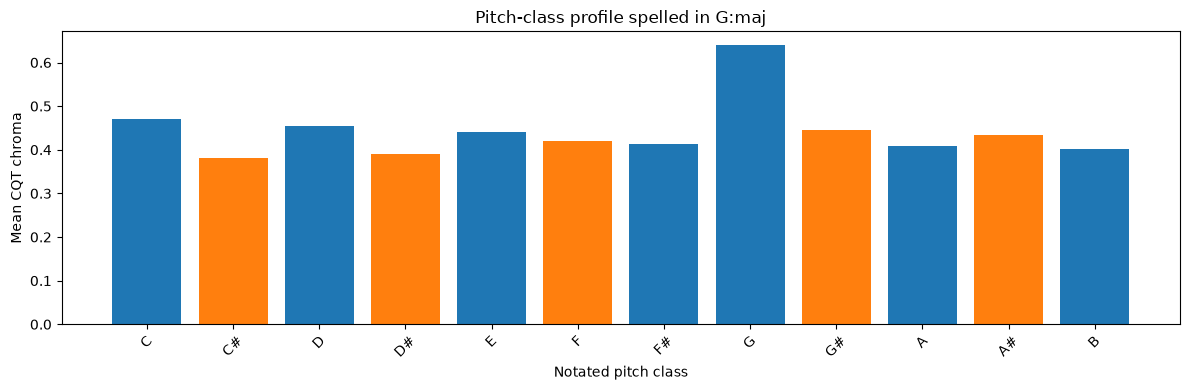

Saved notation outputs to: ../results/librosa/notation


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from IPython.display import display

# Chroma gives pitch classes, not octave-specific notes or a transcribed score.
audio = Path("../audio/Billie Eilish - bad guy.wav")
out_dir = Path("../results/librosa/notation")
out_dir.mkdir(parents=True, exist_ok=True)
y, sr = librosa.load(audio, sr=22050, mono=True)
hop = 2048
chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop)
chroma_profile = chroma.mean(axis=1)

# Rank major/minor key candidates with Krumhansl-Schmuckler-style profiles.
# The top match is a heuristic estimate, not a definitive key transcription.
major_template = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
minor_template = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17])
pitch_class_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
key_candidates = []

for mode, template in [("maj", major_template), ("min", minor_template)]:
    for tonic_index, tonic in enumerate(pitch_class_names):
        rotated_template = np.roll(template, tonic_index)
        correlation = np.corrcoef(chroma_profile, rotated_template)[0, 1]
        key_candidates.append({
            "key": f"{tonic}:{mode}",
            "tonic": tonic,
            "mode": mode,
            "profile_correlation": float(correlation),
        })

key_candidates = pd.DataFrame(key_candidates).sort_values(
    "profile_correlation", ascending=False
).reset_index(drop=True)
best_key = key_candidates.loc[0, "key"]
key_notes = librosa.key_to_notes(best_key, unicode=False)
scale_pitch_classes = librosa.key_to_degrees(best_key)
scale_degree_by_pitch_class = {
    int(pitch_class): degree + 1
    for degree, pitch_class in enumerate(scale_pitch_classes)
}

notation_profile = pd.DataFrame({
    "pitch_class": key_notes,
    "mean_chroma": chroma_profile,
})
notation_profile["scale_degree"] = [
    scale_degree_by_pitch_class.get(pitch_class, "chromatic")
    for pitch_class in range(12)
]
notation_profile["in_scale"] = notation_profile["scale_degree"] != "chromatic"

# Summarize the strongest pitch class and in-scale energy in five-second windows.
frame_times = librosa.frames_to_time(
    np.arange(chroma.shape[1]), sr=sr, hop_length=hop
)
window_seconds = 5
window_ids = np.floor(frame_times / window_seconds).astype(int)
timeline_rows = []
for window_id in np.unique(window_ids):
    in_window = window_ids == window_id
    window_chroma = chroma[:, in_window]
    dominant_pitch_class = int(window_chroma.mean(axis=1).argmax())
    total_energy = window_chroma.sum()
    in_scale_energy = window_chroma[scale_pitch_classes].sum()
    timeline_rows.append({
        "start_seconds": float(window_id * window_seconds),
        "end_seconds": float(min((window_id + 1) * window_seconds, len(y) / sr)),
        "dominant_pitch_class": key_notes[dominant_pitch_class],
        "scale_degree": scale_degree_by_pitch_class.get(dominant_pitch_class, "chromatic"),
        "mean_chroma": float(window_chroma[dominant_pitch_class].mean()),
        "in_scale_energy_share": float(in_scale_energy / max(total_energy, 1e-12)),
    })
notation_timeline = pd.DataFrame(timeline_rows)

key_candidates.to_csv(out_dir / "key_candidates.csv", index=False)
notation_profile.to_csv(out_dir / "pitch_class_notation.csv", index=False)
notation_timeline.to_csv(out_dir / "notation_timeline_5s.csv", index=False)

print(f"Heuristic key estimate: {best_key}")
print(f"Profile correlation: {key_candidates.loc[0, 'profile_correlation']:.3f}")
print(f"Margin to second candidate: {key_candidates.loc[0, 'profile_correlation'] - key_candidates.loc[1, 'profile_correlation']:.3f}")
print("Spelled scale:", [key_notes[int(pitch_class)] for pitch_class in scale_pitch_classes])
print("Top key candidates:")
display(key_candidates.head(5))
print("Mean pitch-class profile and scale-degree spelling:")
display(notation_profile)

bar_colors = [
    "tab:blue" if in_scale else "tab:orange"
    for in_scale in notation_profile["in_scale"]
]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(notation_profile["pitch_class"], notation_profile["mean_chroma"], color=bar_colors)
ax.set(title=f"Pitch-class profile spelled in {best_key}", xlabel="Notated pitch class", ylabel="Mean CQT chroma")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(out_dir / "pitch_class_notation.png", dpi=160)
plt.show()

print("Saved notation outputs to:", out_dir)

## Sequence analysis

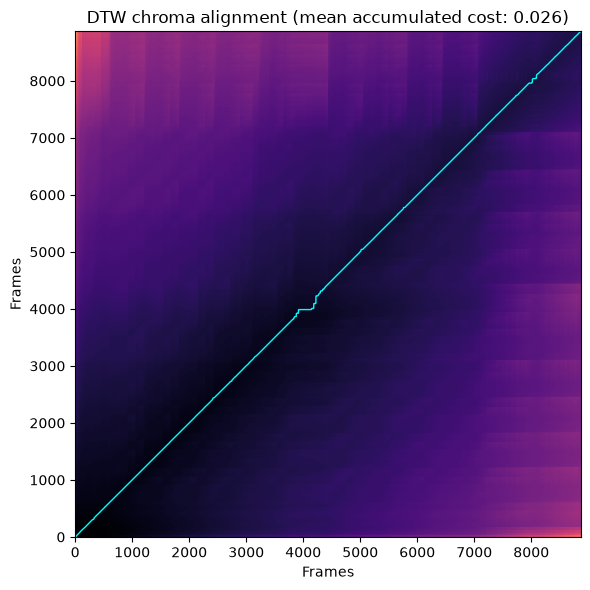

Normalized accumulated DTW cost: 0.0258
Saved alignment and plot to: ../results/librosa/sequence


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

reference = Path("../audio/Billie Eilish - bad guy.wav")
candidate = Path("../results/demucs/bad_guy/htdemucs/Billie Eilish - bad guy/no_vocals.wav")
out_dir = Path("../results/librosa/sequence")
out_dir.mkdir(parents=True, exist_ok=True)

def chroma_features(path):
    y, sr = librosa.load(path, sr=22050, mono=True)
    return librosa.feature.chroma_cqt(y=y, sr=sr)

X = chroma_features(reference)
Y = chroma_features(candidate)

# Normalize each frame so comparison emphasizes pitch-class pattern
X = librosa.util.normalize(X, axis=0)
Y = librosa.util.normalize(Y, axis=0)

D, wp = librosa.sequence.dtw(X=X, Y=Y, metric="cosine")
alignment_cost = float(D[-1, -1] / len(wp))

pd.DataFrame({
    "reference_frame": wp[::-1, 0],
    "candidate_frame": wp[::-1, 1],
}).to_csv(out_dir / "dtw_alignment.csv", index=False)

plt.figure(figsize=(8, 6))
librosa.display.specshow(D, x_axis="frames", y_axis="frames", cmap="magma")
plt.plot(wp[:, 1], wp[:, 0], color="cyan", linewidth=1)
plt.title(f"DTW chroma alignment (mean accumulated cost: {alignment_cost:.3f})")
plt.tight_layout()
plt.savefig(out_dir / "dtw_alignment.png", dpi=160)
plt.show()

print(f"Normalized accumulated DTW cost: {alignment_cost:.4f}")
print("Saved alignment and plot to:", out_dir)


## Beat tracking

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from IPython.display import display

audio = Path("../audio/Billie Eilish - bad guy.wav")
beat_out_dir = Path("../results/librosa/beat")
beat_out_dir.mkdir(parents=True, exist_ok=True)

# Load at a known sample rate so the analysis is independent of earlier cells.
beat_y, beat_sr = librosa.load(audio, sr=22050, mono=True)
hop_length = 512

onset_env = librosa.onset.onset_strength(
    y=beat_y,
    sr=beat_sr,
    hop_length=hop_length,
)

tempo, beat_frames = librosa.beat.beat_track(
    onset_envelope=onset_env,
    sr=beat_sr,
    hop_length=hop_length,
    units="frames",
)

beat_times = librosa.frames_to_time(
    beat_frames,
    sr=beat_sr,
    hop_length=hop_length,
)
tempo_bpm = float(np.asarray(tempo).reshape(-1)[0])

# Estimate tempo between consecutive detected beats.
beat_intervals = np.diff(beat_times)
local_bpm = np.divide(
    60.0,
    beat_intervals,
    out=np.full(beat_intervals.shape, np.nan, dtype=float),
    where=beat_intervals > 0,
)

beat_analysis = pd.DataFrame({
    "beat_number": np.arange(1, len(beat_times) + 1),
    "time_seconds": beat_times,
    "interval_from_previous_seconds": np.r_[np.nan, beat_intervals],
    "local_bpm": np.r_[np.nan, local_bpm],
})
beat_analysis.to_csv(beat_out_dir / "beat_times.csv", index=False)

# Plot onset strength and mark detected beats.
onset_times = librosa.frames_to_time(
    np.arange(len(onset_env)),
    sr=beat_sr,
    hop_length=hop_length,
)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(onset_times, onset_env, linewidth=0.8, label="Onset strength")
if len(beat_times):
    beat_strengths = np.interp(beat_times, onset_times, onset_env)
    ax.scatter(beat_times, beat_strengths, color="tab:red", s=18, label="Detected beats")
ax.set(
    title=f"Beat tracking (estimated tempo: {tempo_bpm:.1f} BPM)",
    xlabel="Time (seconds)",
    ylabel="Onset strength",
)
ax.legend()
fig.tight_layout()
fig.savefig(beat_out_dir / "beat_tracking.png", dpi=160)
plt.show()

print(f"Estimated tempo: {tempo_bpm:.2f} BPM")
print(f"Detected beats: {len(beat_times)}")
print("Saved beat analysis to:", beat_out_dir)
display(beat_analysis.head())